In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import shap

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor

ROOT = Path.cwd().parents[1]
print(ROOT)

DATA_RAW = ROOT/"data/raw"
DATA_PROCESSED = ROOT/"data/processed"

c:\Users\sebas\PycharmProjects\Git\BoxOffice_Oracle


In [2]:
model_df = pd.read_csv(
    DATA_RAW/"fe_groups/g1.csv"
)

print(model_df.shape)
model_df.head()

(2255, 52)


,Unnamed: 0,tconst,primaryTitle,startYear,opening_weekend_gross,opening_theaters,domestic_release_date,release_type,all_domestic_release_types,distributor,...,final_market_synopsis,g1_prior_same_genre_director_count,g1_prior_same_genre_writer_count,g1_prior_same_genre_actor_1_count,g1_prior_same_genre_actor_2_count,g1_prior_same_genre_actor_3_count,g1_prior_same_genre_distributor_count,g1_prior_same_genre_top3_actor_total,g1_prior_same_genre_top3_actor_max,g1_prior_same_genre_top3_actor_mean
0,0,tt1311067,Halloween II,2009.0,7676836.0,1217.0,1981-10-30,Wide,Wide,Universal,...,Laurie Strode struggles to come to terms with ...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,tt0816462,Conan the Barbarian,2011.0,9479373.0,1358.0,1982-05-14,Wide,Wide,Universal,...,A horde of rampaging warriors massacre the par...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,tt4731008,The Wild Life,2016.0,4001400.0,1140.0,1984-09-28,Wide,Wide,NaN,...,"Flight is the ultimate superpower, an extraord...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,tt1160419,Dune: Part One,2021.0,6025091.0,915.0,1984-12-14,Wide,Wide,Universal,...,"Paul Atreides, a brilliant and gifted young ma...",0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,4,tt1540128,Playing for Keeps,2012.0,1406300.0,1148.0,1986-10-03,Wide,Wide,Universal,...,"A romantic comedy about a charming, down-on-hi...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
target = "log_opening_weekend_gross"

g1_features = [
    'g1_prior_same_genre_director_count',
    'g1_prior_same_genre_writer_count',
    'g1_prior_same_genre_actor_1_count',
    'g1_prior_same_genre_actor_2_count',
    'g1_prior_same_genre_actor_3_count',
    'g1_prior_same_genre_distributor_count',
    'g1_prior_same_genre_top3_actor_total',
    'g1_prior_same_genre_top3_actor_max',
    'g1_prior_same_genre_top3_actor_mean'
]

numeric_features = [
    # "opening_theaters",
    "production_budget",
    "runtime_minutes",
    "release_month",
    "release_day_of_year",
] + g1_features

people_features = [
    "director_id",
    "writer_id",
    "actor_1",
    "actor_2",
    "actor_3",
]

categorical_features = [
    # "release_type",
    "distributor",
    "MPA_rating",
    "genre",
    "subgenre",
    "source",
    "production_method",
    "creative_type",
    "production_countries",
    "languages",
    "franchise"
] + people_features

In [4]:
model_df = model_df[
    model_df["franchise"].isna() |
    (model_df["franchise"].astype(str).str.strip() == "")
].copy()

In [5]:
feature_cols = numeric_features + categorical_features

model_data = model_df[
    feature_cols + [target, "opening_weekend_gross"]
].copy()

X = model_data[feature_cols]
y = model_data[target]

print(X.shape)
print(y.shape)

(1493, 28)
(1493,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
y_test_dollars = np.expm1(y_test)

In [8]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [9]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)

    r2_log = r2_score(y_test, pred_log)
    mae_log = mean_absolute_error(y_test, pred_log)

    pred_dollars = np.expm1(pred_log)

    mae_dollars = mean_absolute_error(y_test_dollars, pred_dollars)

    results = {
        "model": name,
        "r2_log": r2_log,
        "mae_log": mae_log,
        "mae_dollars": mae_dollars
    }

    return results, pred_log, pred_dollars

In [10]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_results, ridge_pred_log, ridge_pred_dollars = evaluate_model(
    "Ridge Baseline",
    ridge_model,
    X_train,
    X_test,
    y_train,
    y_test
)

ridge_results

c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(
c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


{'model': 'Ridge Baseline',
 'r2_log': 0.5044804042309787,
 'mae_log': 0.9152804466087111,
 'mae_dollars': 8044948.794950275}

In [11]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ))
])

xgb_results, xgb_pred_log, xgb_pred_dollars = evaluate_model(
    "XGBoost Baseline",
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

xgb_results

c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(
c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


{'model': 'XGBoost Baseline',
 'r2_log': 0.541953928499372,
 'mae_log': 0.8128237721428792,
 'mae_dollars': 6348122.378442464}

In [12]:
results_df = pd.DataFrame([
    ridge_results,
    xgb_results
])

results_df

,model,r2_log,mae_log,mae_dollars
0,Ridge Baseline,0.504480,0.915280,8.044949e+06
1,XGBoost Baseline,0.541954,0.812824,6.348122e+06


In [13]:
plot_df = pd.DataFrame({
    "actual": y_test_dollars,
    "predicted": xgb_pred_dollars
})

fig = px.scatter(
    plot_df,
    x="actual",
    y="predicted",
    title="XGBoost Baseline: Actual vs Predicted",
    opacity=0.6
)

fig.add_shape(
    type="line",
    x0=plot_df["actual"].min(),
    y0=plot_df["actual"].min(),
    x1=plot_df["actual"].max(),
    y1=plot_df["actual"].max(),
)

fig.show()

In [14]:
X_train_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_train)
)

X_test_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_test)
)

feature_names = (
    xgb_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

trained_xgb = xgb_model.named_steps["model"]

c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(
c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


In [15]:
explainer = shap.TreeExplainer(trained_xgb)

X_shap = X_test_transformed[:500]

shap_values = explainer.shap_values(X_shap)

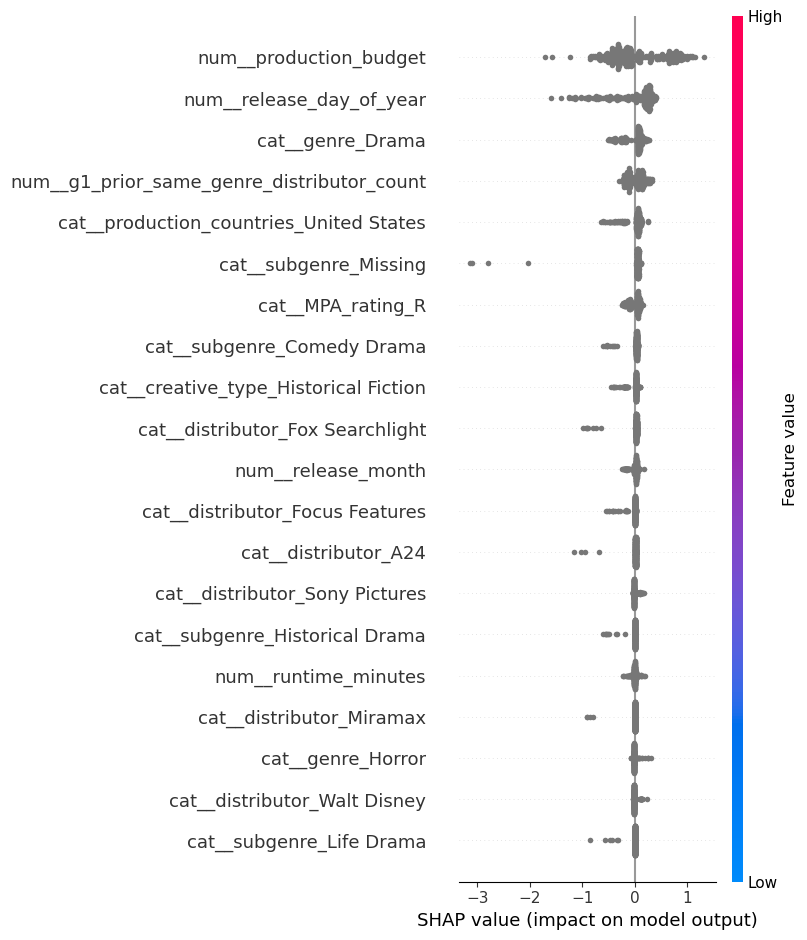

In [16]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names
)

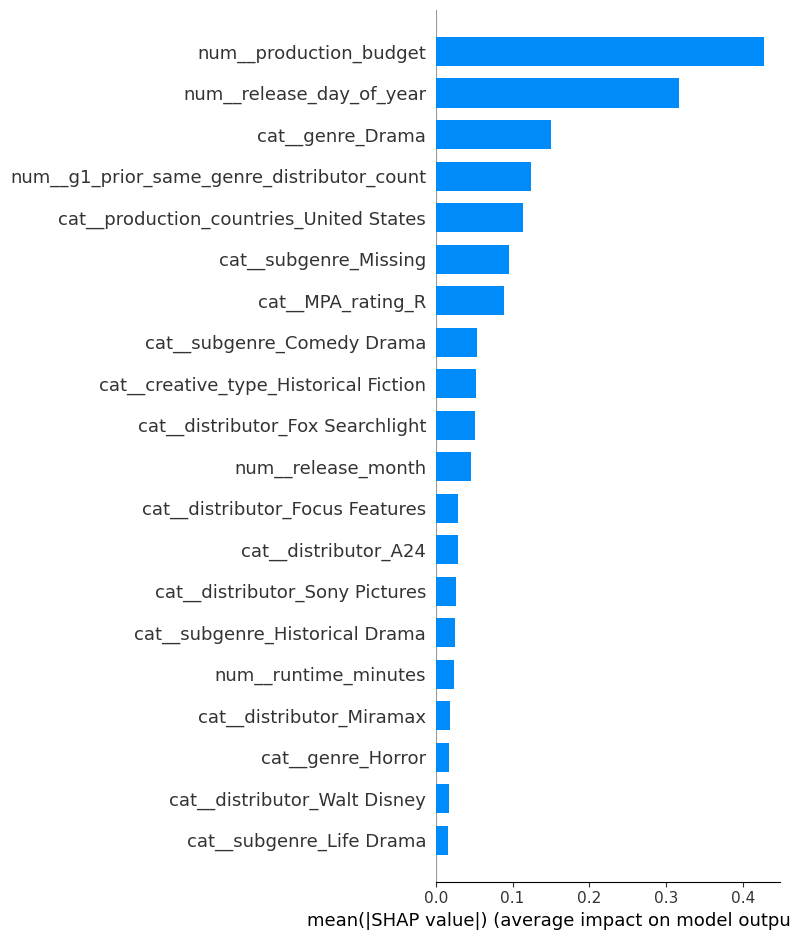

In [17]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar"
)

In [18]:
error_df = X_test.copy()

error_df["actual_log"] = y_test
error_df["pred_log"] = xgb_pred_log

error_df["actual_opening_weekend"] = np.expm1(y_test)
error_df["pred_opening_weekend"] = xgb_pred_dollars

error_df["abs_error"] = (
    error_df["actual_opening_weekend"] -
    error_df["pred_opening_weekend"]
).abs()

error_df.sort_values("abs_error", ascending=False).head(20)

,production_budget,runtime_minutes,release_month,release_day_of_year,g1_prior_same_genre_director_count,g1_prior_same_genre_writer_count,g1_prior_same_genre_actor_1_count,g1_prior_same_genre_actor_2_count,g1_prior_same_genre_actor_3_count,g1_prior_same_genre_distributor_count,...,director_id,writer_id,actor_1,actor_2,actor_3,actual_log,pred_log,actual_opening_weekend,pred_opening_weekend,abs_error
39,25000000.0,127.0,2,56,0.0,0.0,0.0,0.0,0.0,0.0,...,nm0000154,nm0280179,nm0001029,nm0000899,nm0411581,18.244517,15.895287,83848082.0,8002675.0,75845407.0
77,125000000.0,123.0,5,149,0.0,0.0,0.0,0.0,0.0,1.0,...,nm0000386,nm0000386,nm0000598,nm0350453,nm0002536,18.045894,17.032867,68743584.0,24962056.0,43781528.0
1393,95000000.0,105.0,3,72,0.0,0.0,0.0,0.0,0.0,22.0,...,nm7633075,nm7633074,nm11673205,nm7633076,nm8063245,18.033213,17.252789,67877361.0,31102180.0,36775181.0
1795,55000000.0,134.0,11,306,0.0,1.0,0.0,0.0,0.0,23.0,...,nm0001741,nm0565026,nm1785339,nm2377903,nm3152605,17.748534,16.482262,51061119.0,14393130.0,36667989.0
742,175000000.0,89.0,5,149,0.0,0.0,0.0,0.0,0.0,29.0,...,nm0230032,nm0677037,nm0000799,nm2973712,nm0001652,18.036617,17.359953,68108790.0,34620376.0,33488414.0
71,170000000.0,132.0,5,128,0.0,0.0,0.0,0.0,0.0,2.0,...,nm0814085,nm0814085,nm0413168,nm0000295,nm0746896,17.761897,16.964653,51748040.0,23316060.0,28431980.0
1557,60000000.0,96.0,9,253,10.0,0.0,3.0,1.0,0.0,38.0,...,nm0000142,nm0464548,nm0000158,nm0001173,nm0001473,17.371667,15.927505,35028301.0,8264703.5,26763597.5
95,105000000.0,115.0,7,198,0.0,0.0,0.0,0.0,0.0,1.0,...,nm0001639,nm0899113,nm0000226,nm0005256,nm0339304,17.770208,17.098808,52179887.0,26663556.0,25516331.0
990,200000000.0,113.0,6,168,1.0,0.0,0.0,0.0,0.0,18.0,...,nm0132709,nm0075528,nm0005351,nm0515116,nm0765597,17.789086,17.146469,53174303.0,27965136.0,25209167.0
1549,19000000.0,85.0,8,225,0.0,0.0,3.0,1.0,2.0,41.0,...,nm0862911,nm3773434,nm0736622,nm1325419,nm1706767,17.349592,16.186935,34263534.0,10712645.0,23550889.0


In [19]:
results_df.to_csv(
    DATA_PROCESSED/"feature_testing/results/g1_model_results.csv",
    index=False
)

error_df.to_csv(
    DATA_PROCESSED/"feature_testing/errors/g1_xgb_test_errors.csv",
    index=False
)